In [1]:
import cv2
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

## Load images dataset

In [2]:
from PIL import Image

IMAGE_DIR = "../fashion_images/dataset_clean"

images = []
image_paths = []

# iterate to call images data
for root, _, files in os.walk(IMAGE_DIR):
    for filename in files:
        if filename.lower().endswith(".jpg"):
            path = os.path.join(root, filename)
            image = Image.open(path).convert("RGB")
            images.append(image)
            image_paths.append(path)
    
print(f"Loaded {len(images)} JPG Images")

Loaded 8625 JPG Images


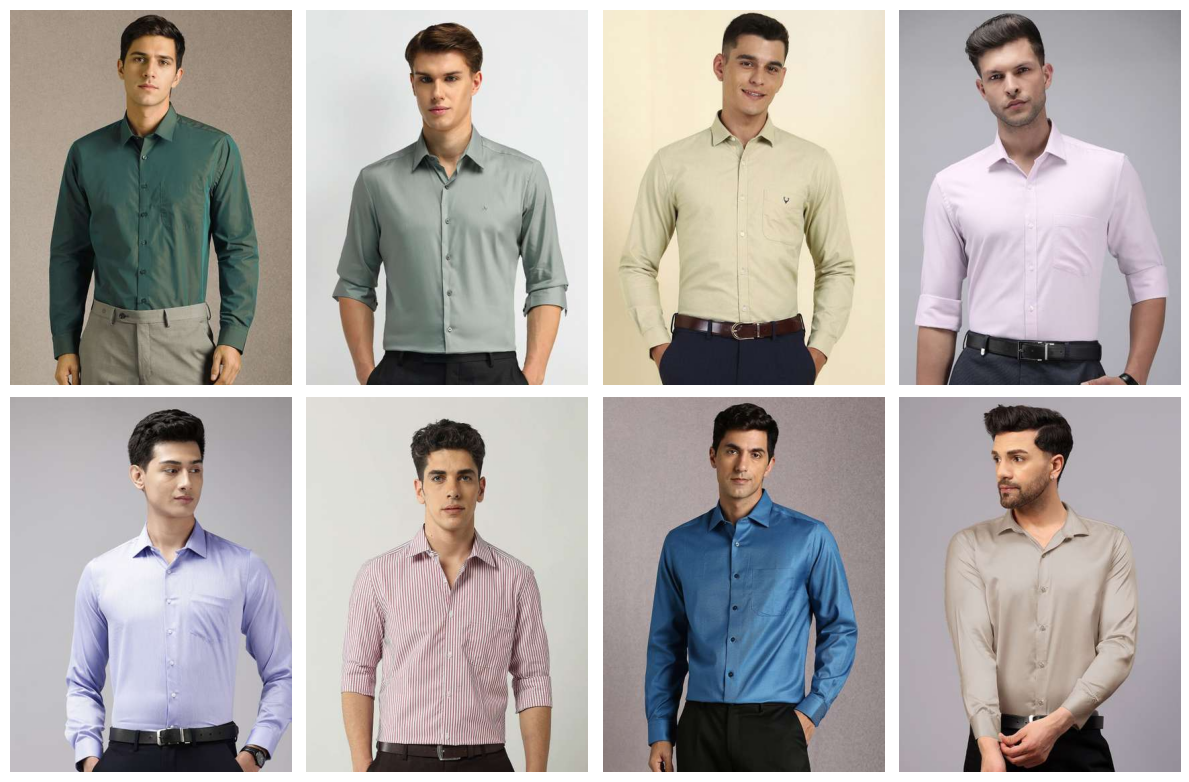

In [3]:
# show multiple images
import matplotlib.pyplot as plt

def show_images(images, cols=4, figsize=(12, 8)):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=figsize)

    for i, img in enumerate(images):
        plt.subplot(rows, cols,  i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Usage
show_images(images[:8], cols=4)

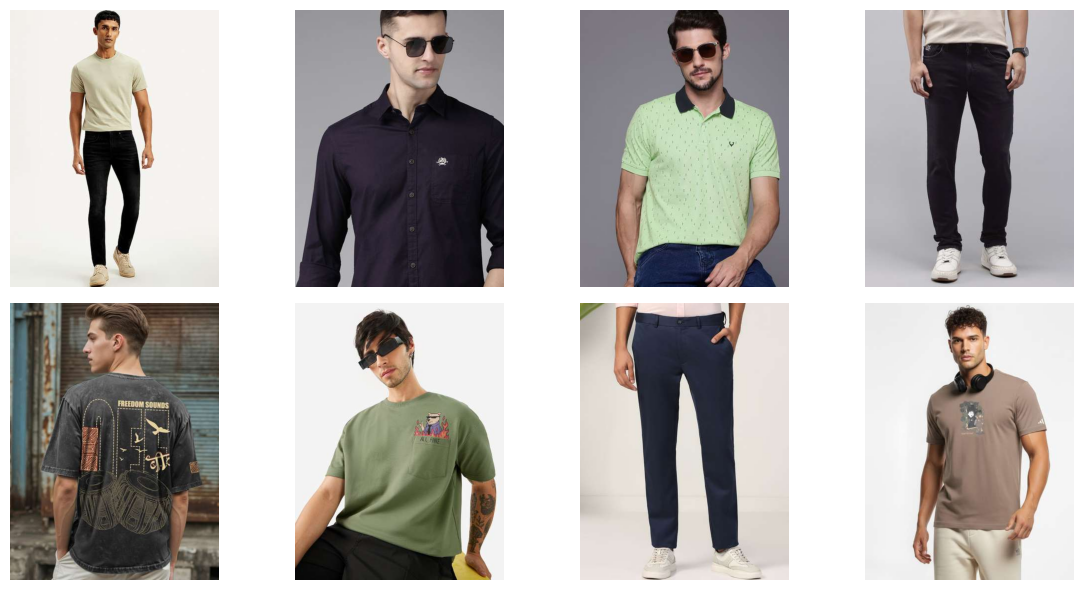

In [4]:
# Show random images

import random
import matplotlib.pyplot as plt

def show_random_images(images, n=8, cols=4, figsize=(12, 6)):
    n = min(n, len(images))
    selected = random.sample(images, n)

    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)

    for i, img in enumerate(selected):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Usage
show_random_images(images, n=8)

# Data pipeline

### 1. Common Matching Scenarios
### 2. Complete Matching Pipeline
### 3. Handle missmatch data pipeline
### 4. Create Image-Metadata Dictionary
### 5. Load and Preprocess Images
### 6. Create Dataset Class for PyTorch
### 7. Quality Checks

## Common Matching Scenarios

In [5]:
from collections import defaultdict

# Direct matching pipeline

# =============================================================================
# CONFIGURATION
# =============================================================================
PARQUET_PATH = "hdfs/fashion_dataset"
IMAGE_DIR = '../fashion_images/dataset_clean'
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.PNG', '.JPEG')

# Load dataset
df = pd.read_parquet(PARQUET_PATH)

# =============================================================================
# SCAN ALL AVAILABLE IMAGES - FIXED TO HANDLE DUPLICATES
# =============================================================================
available_images = {}  # Key: "category_filename" -> Value: full_path
category_counts = defaultdict(int)

print("Scanning images...")

for category in os.listdir(IMAGE_DIR):
    category_path = os.path.join(IMAGE_DIR, category)
    
    if not os.path.isdir(category_path):
        continue
    
    print(f"📁 Scanning: {category}/", end=" ")
    count = 0
    
    for file in os.listdir(category_path):
        if file.endswith(VALID_EXTENSIONS):
            # CREATE UNIQUE KEY: category + filename
            unique_key = f"{category}_{file}"  # e.g., "formal_shirts_img_0235.jpg"
            
            available_images[unique_key] = os.path.join(category_path, file)
            category_counts[category] += 1
            count += 1
    
    print(f"✓ {count:,} images")

# =============================================================================
# RESULTS
# =============================================================================
print("\n" + "="*60)
print("SCAN RESULTS")
print("="*60)
print(f"Total available images: {len(available_images):,}")
print(f"Total dataset rows: {len(df):,}")
print(f"Expected images: 8,625")
print(f"Match rate: {len(available_images)/8625*100:.1f}%")

print("\n=== Images per category ===")
for cat, count in sorted(category_counts.items()):
    print(f"  {cat:20s}: {count:,}")

Scanning images...
📁 Scanning: formal_shirts/ ✓ 992 images
📁 Scanning: printed_tshirts/ ✓ 1,097 images
📁 Scanning: printed_hoodies/ ✓ 1,056 images
📁 Scanning: jeans/ ✓ 1,135 images
📁 Scanning: solid_tshirts/ ✓ 1,040 images
📁 Scanning: formal_pants/ ✓ 986 images
📁 Scanning: casual_shirts/ ✓ 1,182 images
📁 Scanning: men_cargos/ ✓ 1,137 images

SCAN RESULTS
Total available images: 8,625
Total dataset rows: 1,100,000
Expected images: 8,625
Match rate: 100.0%

=== Images per category ===
  casual_shirts       : 1,182
  formal_pants        : 986
  formal_shirts       : 992
  jeans               : 1,135
  men_cargos          : 1,137
  printed_hoodies     : 1,056
  printed_tshirts     : 1,097
  solid_tshirts       : 1,040


In [6]:
# Convert item_id to string for matching
df['item_id_str'] = df['item_id'].astype(str)

## Understand your image naming pattern

In [7]:
sample_images = list(available_images.items())[:10]
print("Sample image filenames:")
for item_id, path in sample_images:
    print(f"  {item_id} -> {os.path.basename(path)}")

Sample image filenames:
  formal_shirts_img_0969.jpg -> img_0969.jpg
  formal_shirts_img_0955.jpg -> img_0955.jpg
  formal_shirts_img_0799.jpg -> img_0799.jpg
  formal_shirts_img_0941.jpg -> img_0941.jpg
  formal_shirts_img_0772.jpg -> img_0772.jpg
  formal_shirts_img_0014.jpg -> img_0014.jpg
  formal_shirts_img_0766.jpg -> img_0766.jpg
  formal_shirts_img_0996.jpg -> img_0996.jpg
  formal_shirts_img_0028.jpg -> img_0028.jpg
  formal_shirts_img_0982.jpg -> img_0982.jpg


## Create mapping by subcategory

In [8]:
print("BUILDING SUBCATEGORY-BASED MAPPING")
print("="*80)

# Group images by subcategory
images_by_subcat = {}
for item_id, path in available_images.items():
    # Extract subcategory from filename
    # Pattern: subcategory_img_XXX.jpg
    if '_img_' in item_id:
        subcat = item_id.split('_img_')[0]
    else:
        # Fallback: use parent directory as category
        subcat = os.path.basename(os.path.dirname(path))
    
    if subcat not in images_by_subcat:
        images_by_subcat[subcat] = []
    images_by_subcat[subcat].append(path)

print(f"Found {len(images_by_subcat)} subcategories:")
for subcat, imgs in sorted(images_by_subcat.items()):
    print(f"  {subcat}: {len(imgs)} images")

BUILDING SUBCATEGORY-BASED MAPPING
Found 8 subcategories:
  casual_shirts: 1182 images
  formal_pants: 986 images
  formal_shirts: 992 images
  jeans: 1135 images
  men_cargos: 1137 images
  printed_hoodies: 1056 images
  printed_tshirts: 1097 images
  solid_tshirts: 1040 images


## Check for naming mismatches

In [9]:
print("CHECKING FOR NAMING MISMATCHES")
print("="*80)

image_subcats = set(images_by_subcat.keys())
df_subcats_set = set(df['subcategory'].unique())

print(f"Subcategories in images: {len(image_subcats)}")
print(f"Subcategories in dataframe: {len(df_subcats_set)}")
print(f"Matching subcategories: {len(image_subcats & df_subcats_set)}")
print(f"Only in images: {len(image_subcats - df_subcats_set)}")
print(f"Only in dataframe: {len(df_subcats_set - image_subcats)}")

if len(image_subcats - df_subcats_set) > 0:
    print("\nSubcategories only in images:")
    for subcat in sorted(list(image_subcats - df_subcats_set))[:5]:
        print(f"  - {subcat}")

if len(df_subcats_set - image_subcats) > 0:
    print("\nSubcategories only in dataframe:")
    for subcat in sorted(list(df_subcats_set - image_subcats))[:5]:
        print(f"  - {subcat}")


CHECKING FOR NAMING MISMATCHES
Subcategories in images: 8
Subcategories in dataframe: 8
Matching subcategories: 8
Only in images: 0
Only in dataframe: 0


In [10]:
# =============================================================================
# IMPROVED ASSIGNMENT STRATEGY
# =============================================================================
print("\n" + "="*80)
print("ASSIGNING IMAGES TO ITEMS")
print("="*80)

# Strategy 1: Try to match by subcategory with sequential assignment
def assign_image_sequential(subcategory, idx_within_subcat):
    """Assign images sequentially within each subcategory"""
    if subcategory in images_by_subcat:
        images = images_by_subcat[subcategory]
        if len(images) > 0:
            # Use modulo to cycle through available images
            return images[idx_within_subcat % len(images)]
    return None

# Group dataframe by subcategory and assign sequentially
df['idx_within_subcat'] = df.groupby('subcategory').cumcount()
df['image_path'] = df.apply(
    lambda row: assign_image_sequential(row['subcategory'], row['idx_within_subcat']), 
    axis=1
)

matched = df['image_path'].notna().sum()
match_rate = (matched / len(df)) * 100

print(f"✓ Assigned images: {matched:,} / {len(df):,} ({match_rate:.2f}%)")

# Statistics by subcategory
print("\nAssignment Statistics by Subcategory:")
assignment_stats = df.groupby('subcategory').agg({
    'image_path': lambda x: x.notna().sum(),
    'item_id': 'count'
}).rename(columns={'image_path': 'matched', 'item_id': 'total'})
assignment_stats['match_rate'] = (assignment_stats['matched'] / assignment_stats['total'] * 100).round(2)
assignment_stats = assignment_stats.sort_values('total', ascending=False).head(10)
print(assignment_stats)

# =============================================================================
# ALTERNATIVE: FUZZY MATCHING (if subcategories don't match exactly)
# =============================================================================
print("\n" + "="*80)
print("OPTIONAL: FUZZY MATCHING FOR MISMATCHED SUBCATEGORIES")
print("="*80)

from difflib import get_close_matches

# Create fuzzy mapping for mismatched subcategories
fuzzy_mapping = {}
for df_subcat in df_subcats_set - image_subcats:
    # Find closest match in image subcategories
    matches = get_close_matches(df_subcat, image_subcats, n=1, cutoff=0.6)
    if matches:
        fuzzy_mapping[df_subcat] = matches[0]
        print(f"  '{df_subcat}' -> '{matches[0]}'")

if fuzzy_mapping:
    print(f"\nFound {len(fuzzy_mapping)} fuzzy matches")
    
    # Apply fuzzy mapping
    def assign_with_fuzzy(row):
        if pd.isna(row['image_path']):
            mapped_subcat = fuzzy_mapping.get(row['subcategory'])
            if mapped_subcat:
                return assign_image_sequential(mapped_subcat, row['idx_within_subcat'])
        return row['image_path']
    
    df['image_path'] = df.apply(assign_with_fuzzy, axis=1)
    
    new_matched = df['image_path'].notna().sum()
    print(f"✓ After fuzzy matching: {new_matched:,} / {len(df):,} ({new_matched/len(df)*100:.2f}%)")


ASSIGNING IMAGES TO ITEMS
✓ Assigned images: 1,100,000 / 1,100,000 (100.00%)

Assignment Statistics by Subcategory:
                 matched   total  match_rate
subcategory                                 
formal_pants      183896  183896       100.0
jeans             183814  183814       100.0
men_cargos        183290  183290       100.0
formal_shirts     110129  110129       100.0
casual_shirts     110045  110045       100.0
printed_tshirts   109825  109825       100.0
solid_tshirts     109775  109775       100.0
printed_hoodies   109226  109226       100.0

OPTIONAL: FUZZY MATCHING FOR MISMATCHED SUBCATEGORIES


## Save results

In [11]:
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Create comprehensive metadata
image_metadata = {}
for idx, row in df[df['image_path'].notna()].iterrows():
    img_path = row['image_path']
    if img_path not in image_metadata:
        image_metadata[img_path] = {
            "image_path": img_path,
            "subcategory": row['subcategory'],
            "category": row['category'],
            "items": []
        }
    
    image_metadata[img_path]["items"].append({
        "item_id": row['item_id'],
        "price": row.get('price', 0),
        "brand": row.get('brand', ''),
        "sleeve_type": row.get('sleeve_type', ''),
        "stocks": row.get('stocks', 0)
    })

# Save metadata
import pickle
with open('image_metadata.pkl', 'wb') as f:
    pickle.dump(image_metadata, f)

print(f"✓ Created metadata for {len(image_metadata):,} unique images")
print(f"✓ Total item-image mappings: {matched:,}")


SAVING RESULTS
✓ Created metadata for 8,625 unique images
✓ Total item-image mappings: 1,100,000


In [12]:
# Summary statistics
print("\n=== FINAL STATISTICS ===")
print(f"Total images available: {len(available_images):,}")
print(f"Total dataset rows: {len(df):,}")
print(f"Rows with images: {matched:,}")
print(f"Unique images used: {len(image_metadata):,}")
print(f"Match rate: {match_rate:.2f}%")

# Check image reuse
items_per_image = [len(v['items']) for v in image_metadata.values()]
print(f"\nImage Reuse Statistics:")
print(f"  Min items per image: {min(items_per_image)}")
print(f"  Max items per image: {max(items_per_image)}")
print(f"  Avg items per image: {np.mean(items_per_image):.1f}")


=== FINAL STATISTICS ===
Total images available: 8,625
Total dataset rows: 1,100,000
Rows with images: 1,100,000
Unique images used: 8,625
Match rate: 100.00%

Image Reuse Statistics:
  Min items per image: 93
  Max items per image: 187
  Avg items per image: 127.5


In [18]:
pd.read_parquet("../data/matched_fashion_dataset.parquet")

,item_id,category,subcategory,sleeve_type,season,fabric,occasion,formality_level,size_range,brand,view_count,click_count,purchase_count,length_cm,price,stocks,item_id_str,idx_within_subcat,image_path
0,TNC_000001,bottoms,men_cargos,long,winter,polyester,casual,high,S,Tommy Hilfiger,93,192,4,97,262476,35,TNC_000001,0,../fashion_images/dataset_clean/men_cargos/img_0969.jpg
1,TNC_000002,tops,formal_shirts,long,winter,linen,party,medium,S,HnM,2941,84,5,77,266987,182,TNC_000002,0,../fashion_images/dataset_clean/formal_shirts/img_0969.jpg
2,TNC_000003,tops,formal_shirts,long,winter,denim,party,high,XL,HnM,401,434,35,71,286065,32,TNC_000003,1,../fashion_images/dataset_clean/formal_shirts/img_0955.jpg
3,TNC_000004,tops,printed_tshirts,short,all-season,linen,office,low,XXL,Tommy Hilfiger,318,85,101,70,153376,149,TNC_000004,0,../fashion_images/dataset_clean/printed_tshirts/img_0969.jpg
4,TNC_000005,tops,formal_shirts,long,all-season,polyester,casual,low,L,ZARA,857,153,67,69,323155,43,TNC_000005,2,../fashion_images/dataset_clean/formal_shirts/img_0799.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099995,TNC_1099996,tops,solid_tshirts,short,summer,polyester,party,medium,M,HnM,2924,183,2,73,140786,163,TNC_1099996,109772,../fashion_images/dataset_clean/solid_tshirts/img_0492.jpg
1099996,TNC_1099997,bottoms,formal_pants,long,summer,denim,party,high,XXL,Polo,2362,94,32,95,353863,198,TNC_1099997,183895,../fashion_images/dataset_clean/formal_pants/img_0123.jpg
1099997,TNC_1099998,bottoms,men_cargos,long,winter,fleece,casual,low,M,Adidas,617,147,39,97,299627,78,TNC_1099998,183289,../fashion_images/dataset_clean/men_cargos/img_0415.jpg
1099998,TNC_1099999,tops,solid_tshirts,short,summer,cotton,office,low,XXL,Tommy Hilfiger,326,0,25,71,153123,172,TNC_1099999,109773,../fashion_images/dataset_clean/solid_tshirts/img_0486.jpg
